Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   subject_id    100000 non-null  int64  
 1   hadm_id       100000 non-null  int64  
 2   stay_id       100000 non-null  int64  
 3   caregiver_id  95386 non-null   float64
 4   charttime     100000 non-null  str    
 5   storetime     99850 non-null   str    
 6   itemid        100000 non-null  int64  
 7   value         96770 non-null   str    
 8   valuenum      42114 non-null   float64
 9   valueuom      26711 non-null   str    
 10  warning       99850 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 13.0 MB
None

Top 10 Vital Signs (itemid):
itemid
227969    3059
220045    2346
220210    2344
220277    2273
220048    2051
224650    1713
220180    1380
220181    1378
220179    1378
227958    1004
Name: count, dtype: int64


<Figure size 1200x600 with 0 Axes>

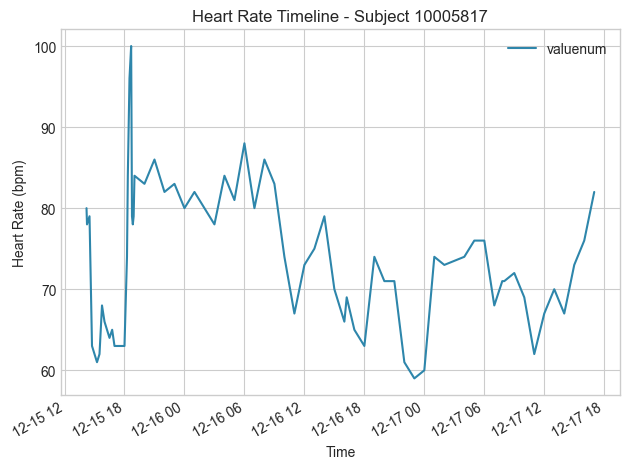


Heart Rate Stats (bpm):
count     74.000000
mean      73.837838
std        9.375028
min       59.000000
25%       66.000000
50%       73.500000
75%       80.000000
max      100.000000
Name: valuenum, dtype: float64

Ready for Day 2: Kafka Producer Setup


In [ ]:
# =============================================================================
# DAY 1: MIMIC-IV Demo Exploration – Verify the "Heartbeat"
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#059669"])

# Load vitals (adjust path if needed)
vitals_path = '../data/raw/icu/chartevents.csv'
df_vitals = pd.read_csv(vitals_path, nrows=100000)  # Limit for speed

print("Dataset Info:")
print(df_vitals.info())
print("\nTop 10 Vital Signs (itemid):")
print(df_vitals['itemid'].value_counts().head(10))

# Sample patient timeline (first subject_id)
sample_subject = df_vitals['subject_id'].iloc[0]
df_sample = df_vitals[df_vitals['subject_id'] == sample_subject].copy()

# Convert time
df_sample['charttime'] = pd.to_datetime(df_sample['charttime'])

# Filter common vitals (examples: Heart Rate = 220045, Glucose = 225664)
heart_rate = df_sample[df_sample['itemid'] == 220045]
glucose = df_sample[df_sample['itemid'] == 225664]

# Plot Heart Rate over time
if not heart_rate.empty:
    plt.figure(figsize=(12, 6))
    heart_rate.sort_values('charttime').plot(x='charttime', y='valuenum', 
                                             title=f'Heart Rate Timeline - Subject {sample_subject}', 
                                             ylabel='Heart Rate (bpm)', xlabel='Time')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('../images/day1_heart_rate_timeline.png', dpi=300)
    plt.show()
else:
    print("No Heart Rate data for this sample patient.")

# Basic stats
print("\nHeart Rate Stats (bpm):")
print(heart_rate['valuenum'].describe())
